# Chương 3. Thiết lập và phân tích tương quan danh mục

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA_PATH = "../data/processed_portfolio_2023_2024.csv"
OUT_DIR = "../outputs"
FIG_DIR = "../figures"

print("Thư mục đang chạy:", os.getcwd())
assert os.path.exists(DATA_PATH), f"Không tìm thấy file: {os.path.abspath(DATA_PATH)}"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

ASSETS = ["BTC_Return", "GLD_Return", "SPY_Return"]
LABELS = {"BTC_Return": "BTC", "GLD_Return": "GLD", "SPY_Return": "SPY"}
TRADING_DAYS = 252

returns = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)[ASSETS]
print("Nguồn dữ liệu:", DATA_PATH)
print("Kích thước:", returns.shape, "| từ", returns.index.min().date(), "đến", returns.index.max().date())
print("Giá trị thiếu:", int(returns.isnull().sum().sum()))
returns.head()

Thư mục đang chạy: D:\HK7\Trí tuệ dn (T6)\BI_Nhom7\Homework\HW05_Portfolio_VaR\notebook
Nguồn dữ liệu: ../data/processed_portfolio_2023_2024.csv
Kích thước: (501, 3) | từ 2023-01-04 đến 2024-12-31
Giá trị thiếu: 0


,BTC_Return,GLD_Return,SPY_Return
Date,,,
2023-01-04,0.010934,0.009368,0.007691
2023-01-05,-0.001573,-0.012530,-0.011479
2023-01-06,0.006821,0.018535,0.022673
2023-01-09,0.014325,0.002243,-0.000567
2023-01-10,0.014418,0.003669,0.006989


## 3.1. Cấu trúc và phương pháp chia tỷ trọng

In [14]:
from scipy.optimize import minimize

mu_daily = returns.mean()
sigma_daily = returns.std()          # ddof=1
cov = returns.cov()

# 1) Equal weight
w_equal = np.repeat(1/3, 3)

# 2) Inverse volatility:
inv_vol = 1 / sigma_daily.values
w_invvol = inv_vol / inv_vol.sum()

# 3) Minimum variance:
def port_var(w, S): return w @ S @ w
res = minimize(port_var, x0=w_equal, args=(cov.values * 1e4,), method="SLSQP",
               bounds=[(0, 1)]*3, options={"ftol": 1e-12, "maxiter": 1000},
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
assert res.success, res.message
w_minvar = res.x

# 4) Bảo thủ: BTC 10%, GLD 45%, SPY 45%
w_conserv = np.array([0.10, 0.45, 0.45])

weights = pd.DataFrame({
    "Equal Weight":        w_equal,
    "Inverse Volatility":  w_invvol,
    "Minimum Variance":    w_minvar,
    "Bao thu (BTC 10%)":   w_conserv,
}, index=["BTC", "GLD", "SPY"])

assert np.allclose(weights.sum(), 1)
display((weights * 100).round(2).rename_axis("Tài sản (%)"))

CHOSEN = "Equal Weight"
w = weights[CHOSEN].values
print("\nPhương án được chọn:", CHOSEN, "->", dict(zip(weights.index, w.round(4))))

weights_out = weights.T.copy()
weights_out["Chosen"] = (weights_out.index == CHOSEN)
weights_out.to_csv(f"{OUT_DIR}/portfolio_weights.csv", float_format="%.6f")

,Equal Weight,Inverse Volatility,Minimum Variance,Bao thu (BTC 10%)
Tài sản (%),,,,
BTC,33.33,11.60,0.00,10.0
GLD,33.33,41.91,43.98,45.0
SPY,33.33,46.50,56.02,45.0



Phương án được chọn: Equal Weight -> {'BTC': np.float64(0.3333), 'GLD': np.float64(0.3333), 'SPY': np.float64(0.3333)}


## 3.2. Lợi nhuận kỳ vọng của danh mục

In [15]:
def portfolio_stats(w, mu, S, name):
    er_d = float(w @ mu)
    vol_d = float(np.sqrt(w @ S @ w))
    return {
        "Phương án": name,
        "E(Rp) ngày (%)": er_d * 100,
        "E(Rp) năm (%)": er_d * TRADING_DAYS * 100,
        "Vol ngày (%)": vol_d * 100,
        "Vol năm (%)": vol_d * np.sqrt(TRADING_DAYS) * 100,
        "Return/Risk (ngày)": er_d / vol_d,
    }

rows = [portfolio_stats(weights[c].values, mu_daily.values, cov.values, c) for c in weights.columns]
port_compare = pd.DataFrame(rows).set_index("Phương án")
display(port_compare.round(4))

asset_er = pd.DataFrame({
    "E(R) ngày (%)": mu_daily * 100,
    "E(R) năm (%)": mu_daily * TRADING_DAYS * 100,
    "Tỷ trọng (%)": w * 100,
    "Đóng góp vào E(Rp) ngày (%)": w * mu_daily.values * 100,
})
asset_er.index = ["BTC", "GLD", "SPY"]
asset_er["Tỷ lệ đóng góp (%)"] = asset_er["Đóng góp vào E(Rp) ngày (%)"] / asset_er["Đóng góp vào E(Rp) ngày (%)"].sum() * 100
display(asset_er.round(4))

port_ret = returns @ w
port_ret.name = "Portfolio_Return"
print("\nThống kê Portfolio Return (ngày):")
print(port_ret.describe().round(6))
print("Skewness:", round(stats.skew(port_ret), 4), "| Excess kurtosis:", round(stats.kurtosis(port_ret), 4))

port_compare.to_csv(f"{OUT_DIR}/portfolio_return_statistics.csv", float_format="%.6f")


,E(Rp) ngày (%),E(Rp) năm (%),Vol ngày (%),Vol năm (%),Return/Risk (ngày)
Phương án,,,,,
Equal Weight,0.1683,42.4095,1.2504,19.8492,0.1346
Inverse Volatility,0.1115,28.1082,0.7508,11.9193,0.1486
Minimum Variance,0.0818,20.6191,0.6405,10.1674,0.1278
Bao thu (BTC 10%),0.1068,26.9197,0.7262,11.5286,0.1471


,E(R) ngày (%),E(R) năm (%),Tỷ trọng (%),Đóng góp vào E(Rp) ngày (%),Tỷ lệ đóng góp (%)
BTC,0.3439,86.6660,33.3333,0.1146,68.1184
GLD,0.0694,17.4771,33.3333,0.0231,13.7368
SPY,0.0916,23.0854,33.3333,0.0305,18.1448



Thống kê Portfolio Return (ngày):
count    501.000000
mean       0.001683
std        0.012504
min       -0.057053
25%       -0.006522
50%        0.000974
75%        0.008604
max        0.067487
Name: Portfolio_Return, dtype: float64
Skewness: 0.3438 | Excess kurtosis: 2.7882


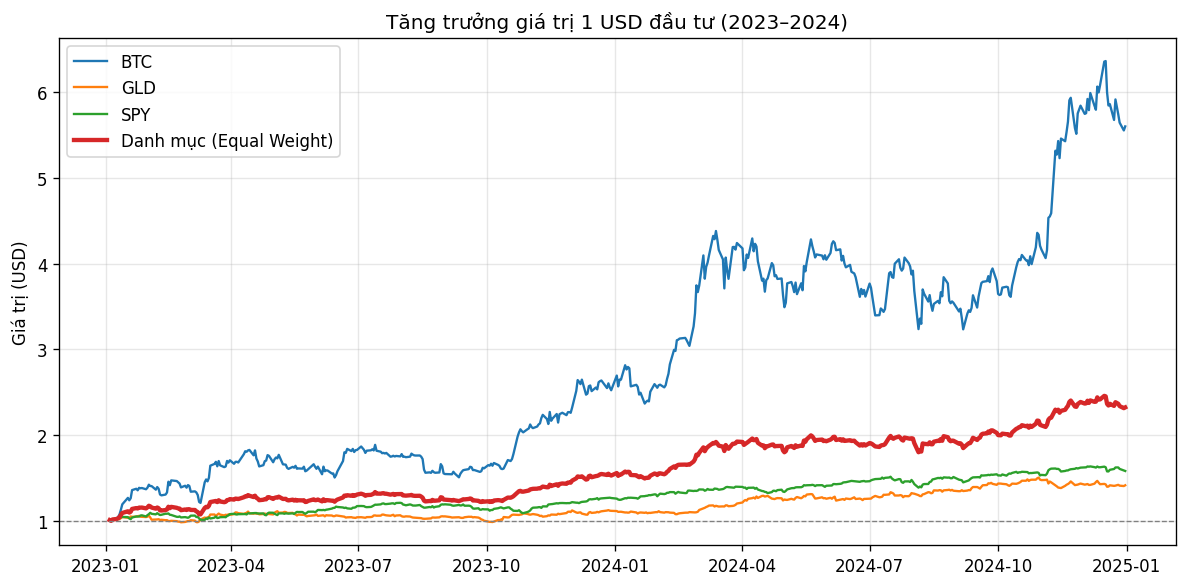

BTC                        460.13
GLD                         41.55
SPY                         58.24
Danh mục (Equal Weight)    132.37
Name: Lợi nhuận tích lũy cuối kỳ (%), dtype: float64


In [16]:
cum = pd.DataFrame({LABELS[c]: np.exp(returns[c].cumsum()) for c in ASSETS})
cum["Danh mục (" + CHOSEN + ")"] = np.exp(port_ret.cumsum())

fig, ax = plt.subplots(figsize=(10, 5))
for col in cum.columns:
    lw = 2.6 if col.startswith("Danh") else 1.4
    ax.plot(cum.index, cum[col], label=col, linewidth=lw)
ax.axhline(1, color="gray", lw=0.8, ls="--")
ax.set_title("Tăng trưởng giá trị 1 USD đầu tư (2023–2024)")
ax.set_ylabel("Giá trị (USD)"); ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cumulative_return.png", dpi=200)
plt.show()

print((cum.iloc[-1] - 1).mul(100).round(2).rename("Lợi nhuận tích lũy cuối kỳ (%)"))

## 3.3. Phân tích ma trận tương quan



In [17]:
corr = returns.corr(method="pearson")
corr_spearman = returns.corr(method="spearman")
corr.index = corr.columns = corr_spearman.index = corr_spearman.columns = ["BTC", "GLD", "SPY"]

display(corr.round(4))
print("Spearman:")
display(corr_spearman.round(4))

pairs = [("BTC_Return", "GLD_Return"), ("BTC_Return", "SPY_Return"), ("GLD_Return", "SPY_Return")]
n = len(returns)
rows = []
for a, b in pairs:
    r, p = stats.pearsonr(returns[a], returns[b])
    rs, ps = stats.spearmanr(returns[a], returns[b])

    z = np.arctanh(r); se = 1/np.sqrt(n-3)
    lo, hi = np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)
    rows.append({"Cặp": f"{LABELS[a]}–{LABELS[b]}", "Pearson r": r, "p-value": p,
                 "CI95% dưới": lo, "CI95% trên": hi, "r²": r**2,
                 "Spearman ρ": rs, "p (Spearman)": ps,
                 "Ý nghĩa 5%": "Có" if p < 0.05 else "Không"})
corr_tests = pd.DataFrame(rows).set_index("Cặp")
display(corr_tests.round(4))

corr.to_csv(f"{OUT_DIR}/correlation_matrix.csv", float_format="%.6f")


,BTC,GLD,SPY
BTC,1.0000,0.0894,0.2686
GLD,0.0894,1.0000,0.1406
SPY,0.2686,0.1406,1.0000


Spearman:


,BTC,GLD,SPY
BTC,1.0000,0.1132,0.2637
GLD,0.1132,1.0000,0.1571
SPY,0.2637,0.1571,1.0000


,Pearson r,p-value,CI95% dưới,CI95% trên,r²,Spearman ρ,p (Spearman),Ý nghĩa 5%
Cặp,,,,,,,,
BTC–GLD,0.0894,0.0456,0.0018,0.1756,0.0080,0.1132,0.0113,Có
BTC–SPY,0.2686,0.0000,0.1854,0.3480,0.0722,0.2637,0.0000,Có
GLD–SPY,0.1406,0.0016,0.0537,0.2255,0.0198,0.1571,0.0004,Có


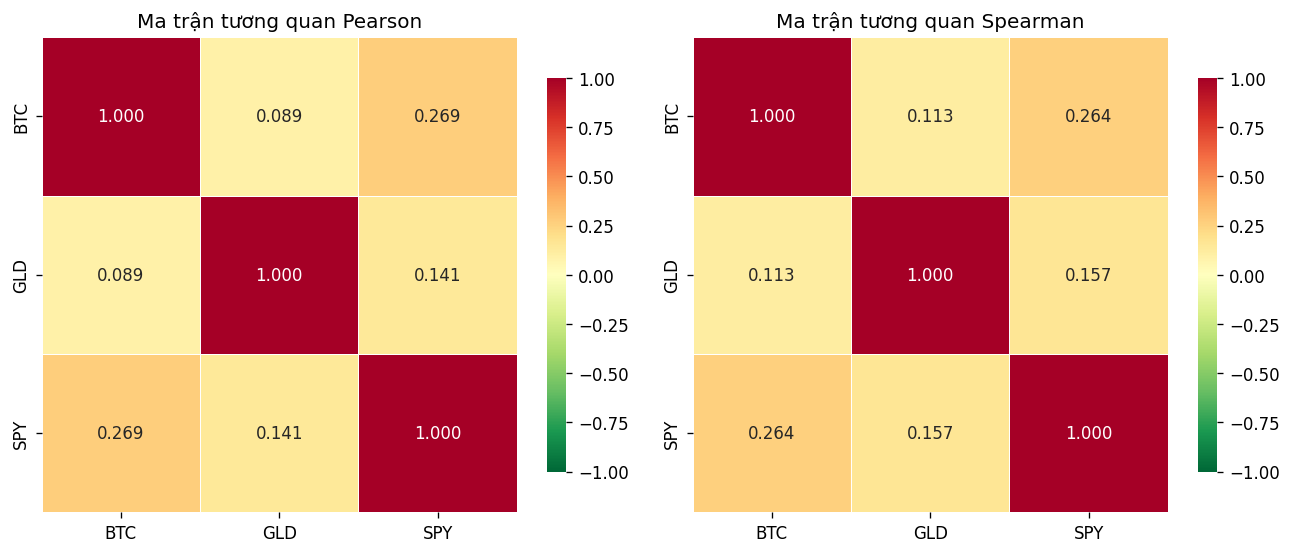

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Ma trận tương quan Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title("Ma trận tương quan Spearman")
for a in axes: a.grid(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=200)
plt.show()

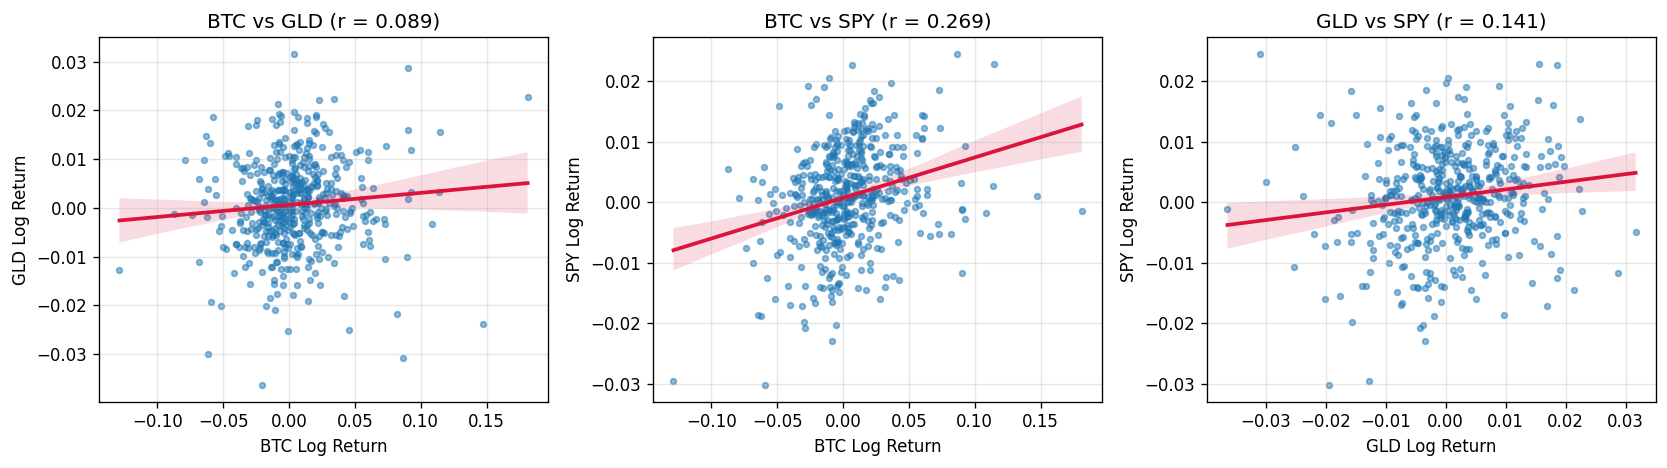

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (a, b) in zip(axes, pairs):
    sns.regplot(x=returns[a], y=returns[b], ax=ax, scatter_kws={"s": 12, "alpha": 0.5},
                line_kws={"color": "crimson"})
    ax.set_xlabel(f"{LABELS[a]} Log Return"); ax.set_ylabel(f"{LABELS[b]} Log Return")
    ax.set_title(f"{LABELS[a]} vs {LABELS[b]} (r = {returns[a].corr(returns[b]):.3f})")
plt.tight_layout()
plt.show()

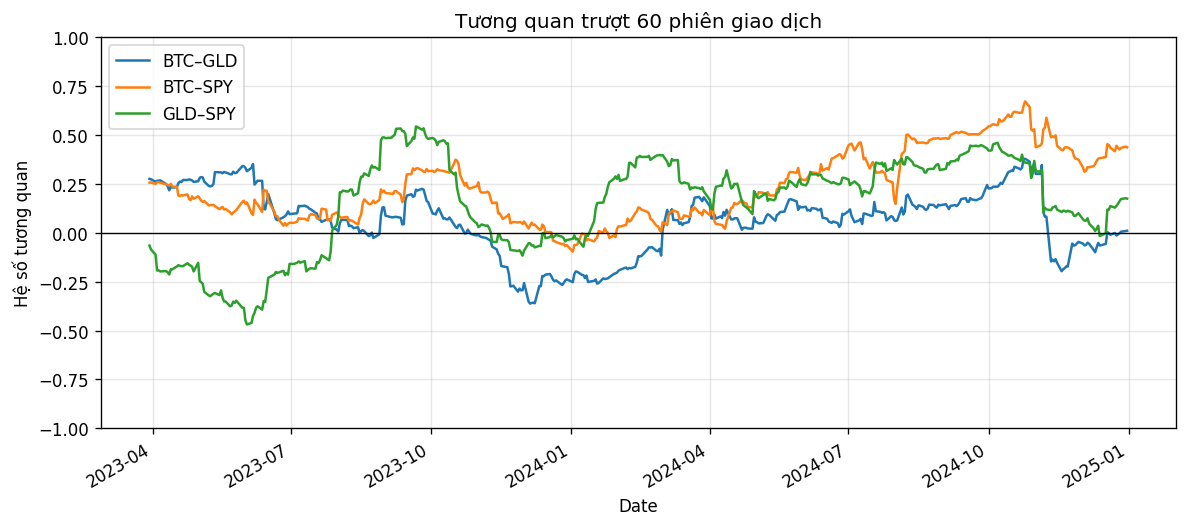

,mean,min,max,std
BTC–GLD,0.0608,-0.3622,0.3779,0.1630
BTC–SPY,0.2348,-0.0966,0.6711,0.1763
GLD–SPY,0.1498,-0.4690,0.5429,0.2404


In [20]:
WIN = 60
roll = pd.DataFrame({
    "BTC–GLD": returns["BTC_Return"].rolling(WIN).corr(returns["GLD_Return"]),
    "BTC–SPY": returns["BTC_Return"].rolling(WIN).corr(returns["SPY_Return"]),
    "GLD–SPY": returns["GLD_Return"].rolling(WIN).corr(returns["SPY_Return"]),
}).dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
roll.plot(ax=ax, linewidth=1.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Tương quan trượt {WIN} phiên giao dịch")
ax.set_ylabel("Hệ số tương quan"); ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

summary_roll = roll.agg(["mean", "min", "max", "std"]).T
display(summary_roll.round(4))


## 3.4. Đánh giá hiệu quả đa dạng hóa

In [10]:
def diversification(w, sigma, S):
    sigma_p = float(np.sqrt(w @ S @ w))
    wavg = float(w @ sigma)
    dr = wavg / sigma_p
    reduction = 1 - sigma_p / wavg
    return sigma_p, wavg, dr, reduction

rows = []
for c in weights.columns:
    sp, wa, dr, red = diversification(weights[c].values, sigma_daily.values, cov.values)
    rows.append({"Phương án": c, "σp ngày (%)": sp*100, "Σwᵢσᵢ (%)": wa*100,
                 "Diversification Ratio": dr, "Giảm rủi ro (%)": red*100})
div_table = pd.DataFrame(rows).set_index("Phương án")
display(div_table.round(4))

sigma_p = np.sqrt(w @ cov.values @ w)
rc = w * (cov.values @ w) / sigma_p**2
risk_contrib = pd.DataFrame({
    "Tỷ trọng vốn (%)": w * 100,
    "Đóng góp rủi ro (%)": rc * 100,
    "Σ (ngày, %)": sigma_daily.values * 100,
}, index=["BTC", "GLD", "SPY"])
display(risk_contrib.round(2))

single = pd.DataFrame({
    "Vol ngày (%)": sigma_daily.values * 100,
    "E(R) ngày (%)": mu_daily.values * 100,
}, index=["BTC", "GLD", "SPY"])
single.loc["Danh mục"] = [sigma_p * 100, float(w @ mu_daily.values) * 100]
display(single.round(4))

,σp ngày (%),Σwᵢσᵢ (%),Diversification Ratio,Giảm rủi ro (%)
Phương án,,,,
Equal Weight,1.2504,1.6475,1.3176,24.1022
Inverse Volatility,0.7508,1.1266,1.5005,33.3560
Minimum Variance,0.6405,0.8466,1.3218,24.3455
Bao thu (BTC 10%),0.7262,1.0906,1.5017,33.4083


,Tỷ trọng vốn (%),Đóng góp rủi ro (%),"Σ (ngày, %)"
BTC,33.33,81.37,3.24
GLD,33.33,8.27,0.90
SPY,33.33,10.35,0.81


,Vol ngày (%),E(R) ngày (%)
BTC,3.2385,0.3439
GLD,0.8962,0.0694
SPY,0.8077,0.0916
Danh mục,1.2504,0.1683


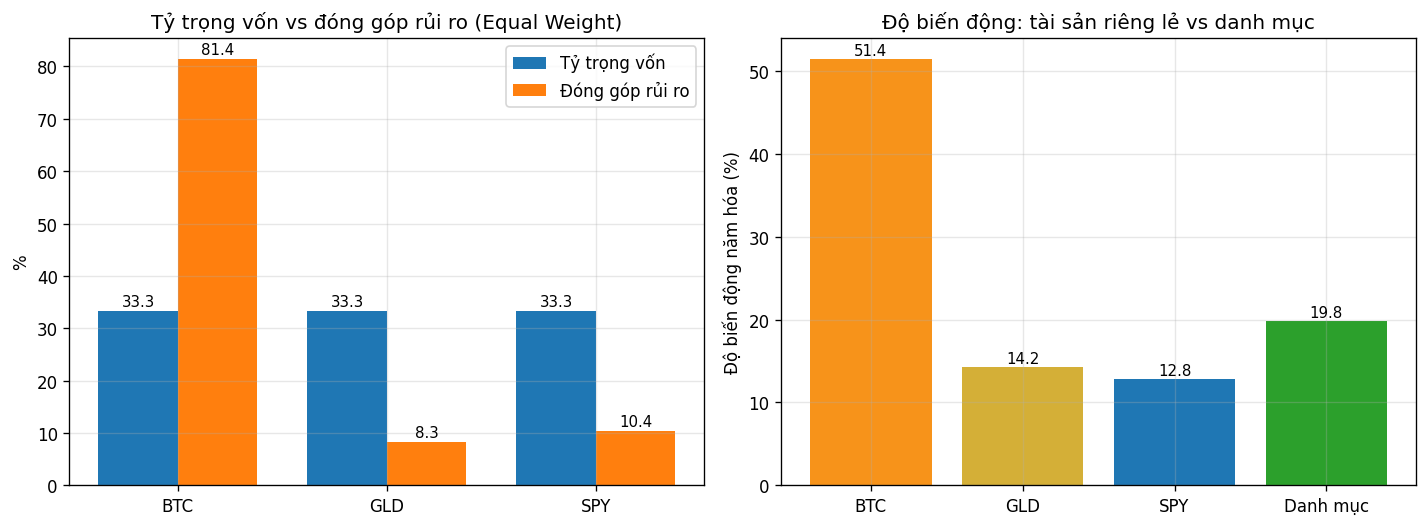

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(3); wd = 0.38
axes[0].bar(x - wd/2, w*100, wd, label="Tỷ trọng vốn")
axes[0].bar(x + wd/2, rc*100, wd, label="Đóng góp rủi ro")
axes[0].set_xticks(x); axes[0].set_xticklabels(["BTC", "GLD", "SPY"])
axes[0].set_ylabel("%"); axes[0].set_title(f"Tỷ trọng vốn vs đóng góp rủi ro ({CHOSEN})")
axes[0].legend()
for i, (a, b) in enumerate(zip(w*100, rc*100)):
    axes[0].text(i - wd/2, a + 1, f"{a:.1f}", ha="center", fontsize=9)
    axes[0].text(i + wd/2, b + 1, f"{b:.1f}", ha="center", fontsize=9)

labels = ["BTC", "GLD", "SPY", "Danh mục"]
vols = list(sigma_daily.values * np.sqrt(TRADING_DAYS) * 100) + [sigma_p * np.sqrt(TRADING_DAYS) * 100]
bars = axes[1].bar(labels, vols, color=["#f7931a", "#d4af37", "#1f77b4", "#2ca02c"])
axes[1].set_ylabel("Độ biến động năm hóa (%)"); axes[1].set_title("Độ biến động: tài sản riêng lẻ vs danh mục")
for b_, v in zip(bars, vols):
    axes[1].text(b_.get_x() + b_.get_width()/2, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
DATA_PATH = "../data/processed_portfolio_2023_2024.csv"
OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

TRADING_DAYS = 252
ASSETS = ["BTC_Return", "GLD_Return", "SPY_Return"]
returns = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)[ASSETS]
mu, cov = returns.mean(), returns.cov()

# 1) portfolio_weights
w_equal = np.repeat(1/3, 3)
inv_vol = 1 / returns.std().values
w_invvol = inv_vol / inv_vol.sum()
from scipy.optimize import minimize
res = minimize(lambda w: w @ (cov.values * 1e4) @ w, x0=w_equal, method="SLSQP",
               bounds=[(0, 1)]*3, options={"ftol": 1e-12, "maxiter": 1000},
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
w_minvar = res.x
w_conserv = np.array([0.10, 0.45, 0.45])

weights = pd.DataFrame({
    "Equal Weight": w_equal,
    "Inverse Volatility": w_invvol,
    "Minimum Variance": w_minvar,
    "Bao thu (BTC 10%)": w_conserv,
}, index=["BTC", "GLD", "SPY"])
CHOSEN = "Equal Weight"
weights_out = weights.T.copy()
weights_out["Chosen"] = (weights_out.index == CHOSEN)
weights_out.to_csv(f"{OUT_DIR}/portfolio_weights.csv", float_format="%.6f")

# 2) portfolio_return_statistics
rows = []
for c in weights.columns:
    w = weights[c].values
    er, vol = float(w @ mu.values), float(np.sqrt(w @ cov.values @ w))
    rows.append({"Phương án": c, "E(Rp) ngày (%)": er*100, "E(Rp) năm (%)": er*TRADING_DAYS*100,
                 "Vol ngày (%)": vol*100, "Vol năm (%)": vol*np.sqrt(TRADING_DAYS)*100,
                 "Return/Risk (ngày)": er/vol})
pd.DataFrame(rows).set_index("Phương án").to_csv(f"{OUT_DIR}/portfolio_return_statistics.csv", float_format="%.6f")

# 3) correlation_matrix
corr = returns.corr()
corr.index = corr.columns = ["BTC", "GLD", "SPY"]
corr.to_csv(f"{OUT_DIR}/correlation_matrix.csv", float_format="%.6f")

print("Các file trong outputs:", sorted(os.listdir(OUT_DIR)))

Các file trong outputs: ['correlation_matrix.csv', 'portfolio_return_statistics.csv', 'portfolio_weights.csv']
